In [ ]:
# ── Notebook parameters ─────────────────────────────────────────
# Defaults for interactive use. extract_notebook_figures.py will
# override these via a cell injected right below this one.
#
# Add notebook-level globals here, e.g.:
CHECKPOINT_DIR  = "../outputs/checkpoints/wandb-xxx"
CHECKPOINT_FILE = "step_xxx.pt"


# 1-D Functional PCA — Discontinuous Sawtooth Toy Dataset

This notebook walks through the 1-D toy FPCA experiment defined by
`OneDimDiscontinuousGenerator`:

$$
f(x) = \begin{cases}
\sin(2\pi k x) + 2x & x \le 0.5 \\\\
\sin\bigl(2\pi k (1-x)\bigr) - 2(1-x) & x > 0.5
\end{cases}
\qquad k \sim \text{Geom}(p) \text{ on } \\{1,2,3,\ldots\\}
$$

For integer $k$, $\sin(\pi k) = 0$, so the left piece climbs from $0$ to $+1$
on $[0, 0.5]$ and the right piece climbs from $-1$ to $0$ on $(0.5, 1]$. The
function therefore has a **jump discontinuity of magnitude 2** at $x=0.5$.
Because $f(0) = f(1) = 0$, on the torus $[0,1)/\\{0\equiv 1\\}$ the only
discontinuity is the interior one at $x=0.5$.

We compare three bases:

1. **1-D Fourier** — orthonormal analytic basis ordered by power-law PMF $\nu_k$.
2. **Learned** — pushforward $Q\phi_k$ from the trained Eulerian isometry.
3. **Coarse-grid PCA** — classical PCA on the corpus evaluated at a small grid;
   the principal directions are discrete vectors and incur discretization error
   when used on a finer test grid.


In [2]:
%load_ext autoreload
%autoreload 2

import sys, os, math
sys.path.append("..")

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate

from infidictionary.datasets import IrregularDataset, OneDimDiscontinuousGenerator
from infidictionary.dictionaries.base import InfiDictionary
from infidictionary.neural_isometries import NeuralIsometry, IdentityIsometry
from infidictionary.networks import NeuralField
from infidictionary.domain_samplers import LineSegmentSampler

from notebook_helpers import plot_spectral_compactness

torch.set_default_dtype(torch.float64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Load a trained checkpoint

Set `CHECKPOINT_DIR` and `CHECKPOINT_FILE` below to a run produced by

```bash
python fpca.py +fpca_experiment=1d_fpca \
    wandb=enabled wandb.run_name=1d_p05
```

If you haven't trained yet, run that first and then re-run this cell.

In [ ]:

with open(f"{CHECKPOINT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

neural_isometry:    NeuralIsometry  = instantiate(conf.neural_isometry).to(device)
mean_function:      NeuralField     = instantiate(conf.mean_function).to(device)
initial_dictionary: InfiDictionary  = instantiate(conf.initial_dictionary)
function_generator: IrregularDataset = instantiate(conf.function_generator)

ckpt = torch.load(f"{CHECKPOINT_DIR}/{CHECKPOINT_FILE}", map_location=device, weights_only=False)
neural_isometry.load_state_dict(ckpt["models"]["neural_isometry"])
mean_function.load_state_dict(ckpt["models"]["mean_function"])

model_state_kwargs = OmegaConf.to_container(
    conf.get("model_state_kwargs", {"num_steps": 20}), resolve=True,
)
neural_isometry.shuffle_model_state(**model_state_kwargs)
neural_isometry.eval(); mean_function.eval()

pullback_kwargs = OmegaConf.to_container(
    conf.get("pullback_pushforward_kwargs", {}), resolve=True,
)

print(f"Loaded   : {CHECKPOINT_DIR}/{CHECKPOINT_FILE}  (epoch {ckpt['epoch']})")
print(f"Metric   : {ckpt['metric']:.4f}  |  best: {ckpt['best_metric']:.4f}")
print(f"Generator: {type(function_generator).__name__}  |  rank: {conf.neural_isometry.rank}")


Loaded   : ../outputs/checkpoints/wandb-5yylqjxg/step_3520.pt  (epoch 3519)
Metric   : 0.3579  |  best: 0.4188
Generator: OneDimDiscontinuousGenerator  |  rank: 30


## 2. Dataset preview

Overlay 128 sample functions from the loaded `function_generator`. Each unique $k$ value gets one colour; the legend entry shows how many times that $k$ appeared in this draw (multiplicity), which reflects the geometric prior $k \sim \text{Geom}(p)$.

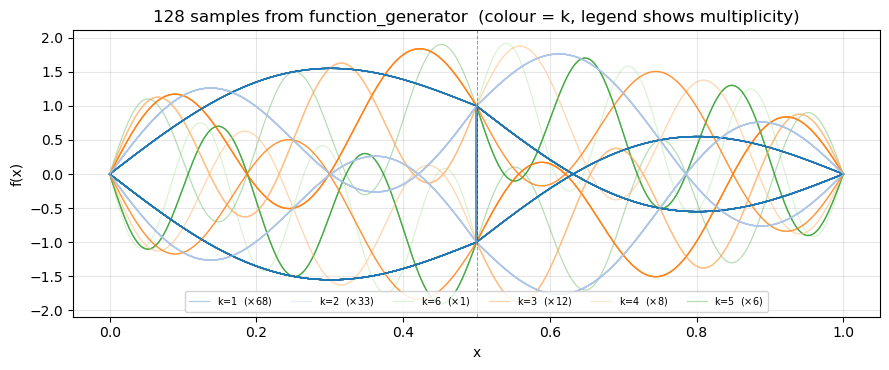

In [4]:
from collections import Counter

# ─── knobs ──────────────────────────────────────────────────────────────────
B_VIS = 128     # number of sample functions to overlay
SEED0 = 1000    # seeds SEED0 … SEED0+B_VIS-1 are used
# ────────────────────────────────────────────────────────────────────────────

x_dense = torch.linspace(0.0, 1.0, 1024).unsqueeze(-1)

# Draw k for every sample upfront so we know the multiplicity.
ks = [function_generator._sample_k(SEED0 + j) for j in range(B_VIS)]
k_counts   = Counter(ks)
k_sorted   = sorted(k_counts.keys())

# Assign a consistent colour to each unique k value.
palette  = plt.cm.tab20.colors
k_color  = {k: palette[i % len(palette)] for i, k in enumerate(k_sorted)}

fig, ax = plt.subplots(figsize=(9, 3.8))
seen = set()
for j in range(B_VIS):
    k = ks[j]
    f = function_generator._eval(x_dense, seed=SEED0 + j).squeeze(-1).numpy()
    cnt   = k_counts[k]
    label = rf"k={k}  ($\times${cnt})" if k not in seen else "_nolegend_"
    seen.add(k)
    ax.plot(x_dense.squeeze(-1).numpy(), f,
            alpha=0.35, lw=0.9, color=k_color[k], label=label)

ax.axvline(0.5, color="k", ls="--", lw=0.7, alpha=0.4)
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
ax.set_title(f"{B_VIS} samples from function_generator  (colour = k, legend shows multiplicity)")
ax.legend(fontsize=7, ncol=8, loc="lower center", framealpha=0.85)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Learned mean function

The training loop fits a `NeuralField` that approximates the empirical mean
$\mu(x) = \mathbb{E}[f(x)]$.  We visualise it here alongside the Monte-Carlo
estimate of the true mean built from the corpus (dashed line).  The two should
agree well once training has converged.

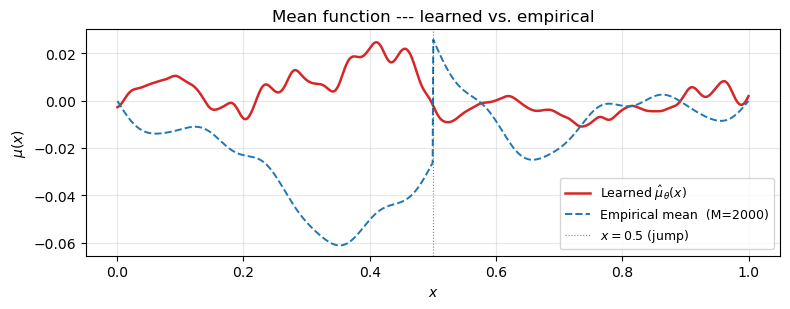

Max pointwise error |learned - empirical|: 0.0774


In [5]:

N_MEAN_VIS  = 1024   # fine grid resolution
M_MEAN_EST  = 2000   # Monte-Carlo samples for the empirical mean

x_vis = LineSegmentSampler(stratified=True, add_noise=False).sample(N_MEAN_VIS)  # (N, 1)
x_vis_dev = x_vis.to(device)

# Learned mean: forward pass on the fine grid.
with torch.no_grad():
    mu_pred = mean_function(x_vis_dev).cpu().squeeze(-1)   # (N,)

# Empirical mean: average M_MEAN_EST draws from the generator.
# Use the same generator that was instantiated from the config.
emp_vals = torch.stack(
    [function_generator._eval(x_vis, seed=s).squeeze(-1) for s in range(M_MEAN_EST)],
    dim=0,
).mean(dim=0)  # (N,)

x_np      = x_vis.squeeze(-1).numpy()
order_x   = np.argsort(x_np)
x_sorted  = x_np[order_x]

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(x_sorted, mu_pred.numpy()[order_x],   color="C3",  lw=1.8,
        label=r"Learned $\hat\mu_\theta(x)$")
ax.plot(x_sorted, emp_vals.numpy()[order_x],  color="C0",  lw=1.4, ls="--",
        label=f"Empirical mean  (M={M_MEAN_EST})")
ax.axvline(0.5, color="k", ls=":", lw=0.8, alpha=0.5, label="$x=0.5$ (jump)")
ax.set_xlabel("$x$"); ax.set_ylabel(r"$\mu(x)$")
ax.set_title("Mean function --- learned vs. empirical")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Max pointwise error |learned - empirical|: "
      f"{np.abs((mu_pred.numpy() - emp_vals.numpy()).max()):.4f}")


## 4. Fourier basis vs. learned principal functions

Plot all atoms from each basis ordered by wavenumber $k$, so the DC mode sits
in the centre. The learned atoms are obtained by pushing each Fourier atom
through the trained isometry $Q$.

/tmp/ipykernel_1242054/1612120022.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();


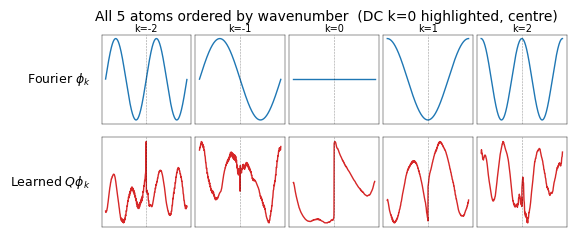

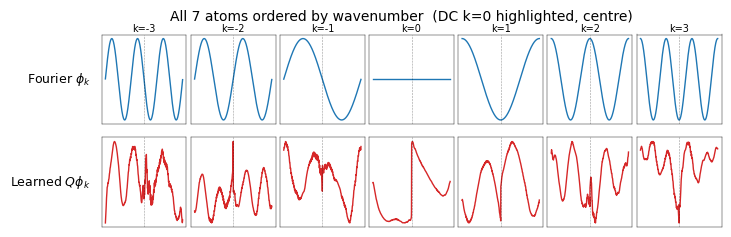

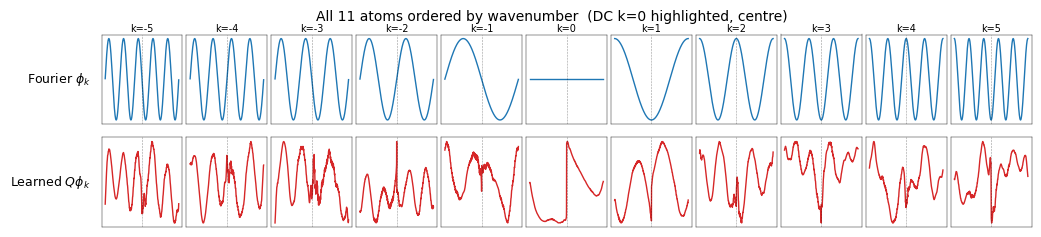

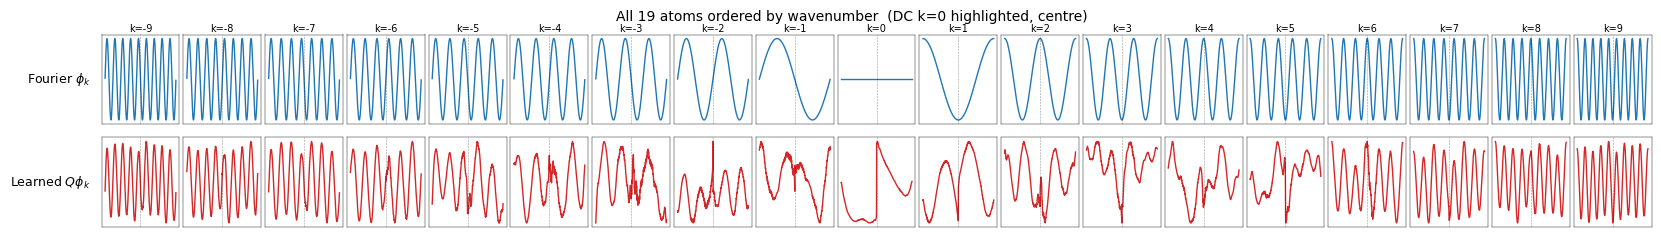

In [6]:
# half-bandwidth (use indices in [-(K-1), K-1])
for K_TRUNC in [3, 4, 6, 10]:
    N_VIS_ATOM = 1024  # fine grid for plotting

    coords_fine = LineSegmentSampler(stratified=True, add_noise=False).sample(N_VIS_ATOM).to(device)
    lad_fine    = torch.zeros(coords_fine.shape[0], device=device)

    # All truncated indices, sorted by wavenumber k ascending so DC (k=0) is centred.
    # For a 1-D FourierDictionary (channels_dim=1) each index row is [k, channel];
    # column 0 is the wavenumber.  Ascending sort: -K+1, ..., -1, 0, 1, ..., K-1.
    indices_all = initial_dictionary.get_truncated_indices(K_TRUNC).to(device)
    nu_all      = initial_dictionary.get_index_pmfs(indices_all)
    order_wn    = indices_all[:, 0].argsort()          # ascending wavenumber
    indices_wn  = indices_all[order_wn]
    nu_wn       = nu_all[order_wn]

    neural_isometry.shuffle_model_state(**model_state_kwargs)
    with torch.no_grad():
        atoms_fourier = initial_dictionary.get_atoms(coords_fine, indices_wn)            # (A, N, 1)
        _, _, atoms_learned = neural_isometry.pushforward(
            coords_fine, lad_fine, atoms_fourier, **pullback_kwargs,
        )                                                                                 # (A, N, 1)

    A          = atoms_fourier.shape[0]
    x_np       = coords_fine.squeeze(-1).cpu().numpy()
    order_x    = np.argsort(x_np)
    x_sorted   = x_np[order_x]

    fig, axes = plt.subplots(2, A,
        figsize=(A * 1.0 + 1.0, 2.5),
        sharex=True, sharey=False, squeeze=False,
        gridspec_kw={"wspace": 0.05, "hspace": 0.15},
    )
    for j in range(A):
        f_F   = atoms_fourier[j].squeeze(-1).cpu().numpy()[order_x]
        f_L   = atoms_learned[j].squeeze(-1).cpu().numpy()[order_x]
        k_val = indices_wn[j, 0].item()
        bg    = "white"   # highlight DC
        axes[0, j].plot(x_sorted, f_F, color="C0", lw=1.0)
        axes[1, j].plot(x_sorted, f_L, color="C3", lw=1.0)
        for r in (0, 1):
            axes[r, j].set_facecolor(bg)
            axes[r, j].axvline(0.5, color="k", ls="--", lw=0.4, alpha=0.4)
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            for sp in axes[r, j].spines.values():
                sp.set_linewidth(0.3)
        axes[0, j].set_title(f"k={k_val}", fontsize=7, pad=2)

    axes[0, 0].set_ylabel(r"Fourier $\phi_k$", fontsize=9, rotation=0,
                        ha="right", va="center", labelpad=8)
    axes[1, 0].set_ylabel(r"Learned $Q\phi_k$", fontsize=9, rotation=0,
                        ha="right", va="center", labelpad=8)
    plt.suptitle(f"All {A} atoms ordered by wavenumber  (DC k=0 highlighted, centre)", fontsize=10)
    plt.tight_layout(); 
    # plt.savefig('fpca_1d_high_res.png', dpi=500, bbox_inches='tight')
    plt.show()

## 5. Coarse-grid PCA baseline

Build a large training corpus and compute classical PCA on it at a **coarse
grid** of $N_{\rm coarse}$ points. Each principal component is just a vector in
$\mathbb{R}^{N_{\rm coarse}}$ — to use it on a finer test grid we have to
interpolate, and the discretization error shows up directly in the captured
energy.

corpus_fine: (2048, 1024, 1)
Top-1 PC explains 62.67% of coarse variance
Top-5 PCs explain 98.13%   of coarse variance


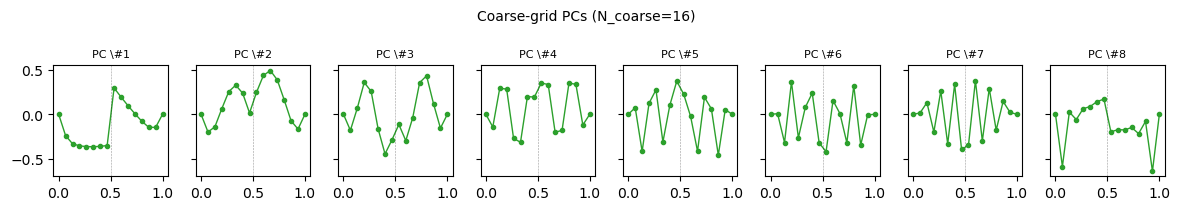

In [7]:
M_CORPUS  = 2048      # corpus size for PCA + energy estimation
N_COARSE  = 16        # coarse grid for the discrete-PCA baseline
N_FINE    = 1024      # fine reference grid (same as N_VIS_ATOM above)

# Reference fine-grid corpus (the "ground truth" L2 evaluation).
x_fine = torch.linspace(0.0, 1.0, N_FINE).unsqueeze(-1)
corpus_fine = torch.stack(
    [function_generator._eval(x_fine, seed=s) for s in range(M_CORPUS)], dim=0,
)  # (M, N_FINE, 1)
print("corpus_fine:", tuple(corpus_fine.shape))

# Coarse-grid corpus + PCA.
x_coarse = torch.linspace(0.0, 1.0, N_COARSE).unsqueeze(-1)
corpus_coarse = torch.stack(
    [function_generator._eval(x_coarse, seed=s) for s in range(M_CORPUS)], dim=0,
).squeeze(-1)  # (M, N_COARSE)

mean_coarse = corpus_coarse.mean(dim=0)
X_centered  = corpus_coarse - mean_coarse
_, S, Vh    = torch.linalg.svd(X_centered, full_matrices=False)
ev          = (S ** 2) / (S ** 2).sum()
print(f"Top-1 PC explains {ev[0].item()*100:.2f}% of coarse variance")
print(f"Top-5 PCs explain {ev[:5].sum().item()*100:.2f}%   of coarse variance")

# Plot top coarse PCs (each is a R^{N_COARSE} vector - show as step-line).
K_PC_SHOW = 8
fig, axes = plt.subplots(1, K_PC_SHOW, figsize=(1.5 * K_PC_SHOW, 2.1),
                         sharey=True, squeeze=False)
xc_np = x_coarse.squeeze(-1).numpy()
for k, ax in enumerate(axes[0]):
    ax.plot(xc_np, Vh[k].cpu().numpy(), "o-", ms=3, lw=1.0, color="C2")
    ax.axvline(0.5, color="k", ls="--", lw=0.4, alpha=0.4)
    ax.set_title(rf"PC \#{k+1}", fontsize=8); ax.set_xticks([0, 0.5, 1])
plt.suptitle(f"Coarse-grid PCs (N_coarse={N_COARSE})", fontsize=10)
plt.tight_layout(); plt.show()


## 6. Reconstructions

Grid layout:

* **rows** = method (Fourier / Coarse PCA / Learned)
* **columns** = signals with distinct $k$

Inside each panel the target (black) is overlaid with reconstructions at
increasing atom budgets — lighter shade = fewer atoms, darker = more.

What to look for:

* **Fourier row**: Gibbs ringing near $x=0.5$ that shrinks but never disappears as $K$ grows.
* **Coarse PCA row**: all K-shades land in the same place — the basis is hard-capped
  at $N_{\rm coarse}$ atoms and can never resolve the jump.
* **Learned row**: already well-fit at small $K$ because the isometry front-loads energy
  into the first few atoms.

selected seeds = [5000, 5001, 5003, 5006]  |  k values = [2, 1, 3, 4]
showing signal index 2  (k = 3,  seed = 5003)


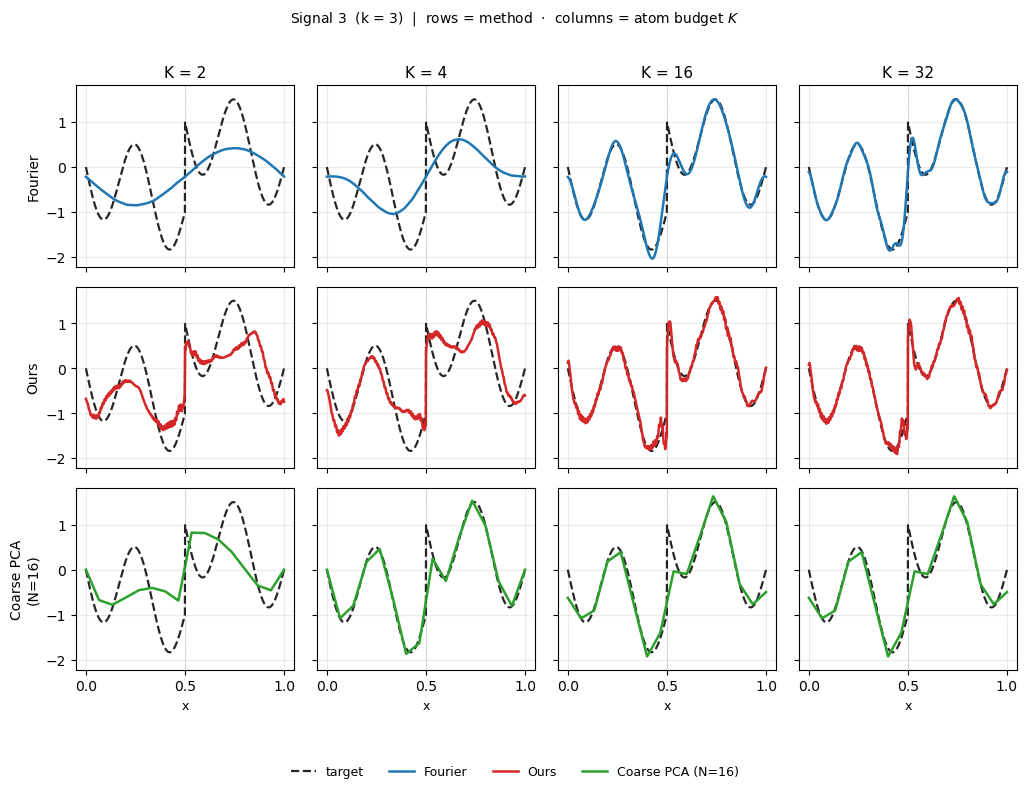

In [8]:
from matplotlib.lines import Line2D

# ─── knobs ──────────────────────────────────────────────────────────────────
K_LIST_RECON = [2, 4, 16, 32]
N_RECON_SHOW = 4      # still build 4 signals; SIG_IDX below picks which one to show
SEED_BASE    = 5000
SIG_IDX      = 2      # 0-indexed — "Sampled Signal 3"
# ────────────────────────────────────────────────────────────────────────────

# ── Sample N_RECON_SHOW distinct-k signals ──────────────────────────────────
chosen_seeds, chosen_ks = [], []
seed = SEED_BASE
while len(chosen_seeds) < N_RECON_SHOW:
    k = function_generator._sample_k(seed)
    if k not in chosen_ks:
        chosen_seeds.append(seed); chosen_ks.append(k)
    seed += 1
print(f'selected seeds = {chosen_seeds}  |  k values = {chosen_ks}')
print(f'showing signal index {SIG_IDX}  (k = {chosen_ks[SIG_IDX]},  seed = {chosen_seeds[SIG_IDX]})')

N_RECON   = x_fine.shape[0]
x_recon   = x_fine.to(device)
lad_recon = torch.zeros(N_RECON, device=device)
targets   = torch.stack([
    function_generator._eval(x_fine, seed=s).squeeze(-1) for s in chosen_seeds
], dim=0).to(device)                                            # (N_RECON_SHOW, N)

xc_np = x_coarse.squeeze(-1).numpy()
xf_np = x_fine.squeeze(-1).numpy()
with torch.no_grad():
    mu_tr = mean_function(x_recon).squeeze(-1)
mu_pca = torch.from_numpy(np.interp(xf_np, xc_np, mean_coarse.numpy())).float().to(device)

# ── Build atoms once at K_MAX, prefix-slice per K ───────────────────────────
K_MAX       = max(K_LIST_RECON)
indices_all = initial_dictionary.get_truncated_indices(K_MAX + 1).to(device)
nu_all      = initial_dictionary.get_index_pmfs(indices_all)
indices_top = indices_all[nu_all.argsort(descending=True)][:K_MAX]
neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_F_max = initial_dictionary.get_atoms(x_recon, indices_top)         # (K_MAX, N, 1)
    _, _, atoms_L_max = neural_isometry.pushforward(
        x_recon, lad_recon, atoms_F_max, **pullback_kwargs,
    )
atoms_F_max = atoms_F_max.squeeze(-1)                                        # (K_MAX, N)
atoms_L_max = atoms_L_max.squeeze(-1)

K_PCA_MAX  = Vh.shape[0]
pcs_raw    = np.stack([np.interp(xf_np, xc_np, Vh[k].cpu().numpy()) for k in range(K_PCA_MAX)])
atoms_PCA_max = torch.from_numpy(pcs_raw).double().to(device)
atoms_PCA_max = atoms_PCA_max / (
    (atoms_PCA_max ** 2).sum(dim=1, keepdim=True) / N_RECON
).sqrt().clamp(min=1e-12)

def reconstruct(atoms, mean, target):
    f_c = target - mean
    return mean + (atoms @ f_c) / N_RECON @ atoms

METHODS_ALL = ['Fourier', 'Coarse PCA', 'Learned']

# ── Precompute all (method, K, signal) reconstructions ──────────────────────
with torch.no_grad():
    recons = {m: {} for m in METHODS_ALL}
    for K in K_LIST_RECON:
        aF = atoms_F_max   [:min(K, atoms_F_max.shape[0])]
        aL = atoms_L_max   [:min(K, atoms_L_max.shape[0])]
        aP = atoms_PCA_max [:min(K, K_PCA_MAX)]
        for c in range(N_RECON_SHOW):
            f = targets[c]
            recons['Fourier']   [(K, c)] = reconstruct(aF, mu_tr,  f).cpu().numpy()
            recons['Learned']   [(K, c)] = reconstruct(aL, mu_tr,  f).cpu().numpy()
            recons['Coarse PCA'][(K, c)] = reconstruct(aP, mu_pca, f).cpu().numpy()

# ── Plot: rows = methods, columns = K values, one fixed signal ───────────────
# Row order and display labels
ROWS = [
    ('Fourier',    'C0', 'Fourier'),
    ('Learned',    'C3', 'Ours'),
    ('Coarse PCA', 'C2', f'Coarse PCA\n(N={N_COARSE})'),
]

fig, axes = plt.subplots(len(ROWS), len(K_LIST_RECON),
                         figsize=(2.6 * len(K_LIST_RECON), 2.6 * len(ROWS)),
                         sharex=True, sharey='all', squeeze=False)

target_np = targets[SIG_IDX].cpu().numpy()

for r, (method, color, row_label) in enumerate(ROWS):
    for c, K in enumerate(K_LIST_RECON):
        ax = axes[r, c]
        ax.plot(xf_np, target_np, color='k', lw=1.6, ls='--', alpha=0.85)
        ax.plot(xf_np, recons[method][(K, SIG_IDX)], color=color, lw=1.8)
        ax.axvline(0.5, color='k', ls=':', lw=0.4, alpha=0.4)
        ax.grid(alpha=0.25)
        ax.set_xticks([0, 0.5, 1])
        if r == 0:
            ax.set_title(f'K = {K}', fontsize=11)
        if c == 0:
            ax.set_ylabel(row_label, fontsize=10)
        if r == len(ROWS) - 1:
            ax.set_xlabel('x', fontsize=9)

legend_handles = [
    Line2D([0], [0], color='k', lw=1.6, ls='--', alpha=0.85, label='target'),
    Line2D([0], [0], color='C0', lw=1.8, label='Fourier'),
    Line2D([0], [0], color='C3', lw=1.8, label='Ours'),
    Line2D([0], [0], color='C2', lw=1.8, label=f'Coarse PCA (N={N_COARSE})'),
]
fig.legend(handles=legend_handles,
           loc='lower center', ncol=4, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    f'Signal {SIG_IDX + 1}  (k = {chosen_ks[SIG_IDX]})  |  '
    r'rows = method  $\cdot$  columns = atom budget $K$',
    fontsize=10,
)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
plt.show()


## 7. Cumulative captured energy

For each basis, estimate the cumulative captured energy as a function of $K$
on the fine corpus. For Fourier and the learned basis, atoms are L²-orthonormal
so the captured fraction is simply

$$
\mathcal{E}_K \;=\; \frac{\sum_{m=1}^{M}\sum_{k=1}^{K} \bigl|\langle f_m - \mu, \phi_k\rangle\bigr|^2}
                       {\sum_{m=1}^{M} \|f_m - \mu\|^2}.
$$

For the coarse-grid PCA baseline, the principal vectors are interpolated to
the fine grid with linear interpolation before projecting — this is where the
discretization gap shows up.

Total centred L2 energy: 1705.8862
Total projection atoms available: 159


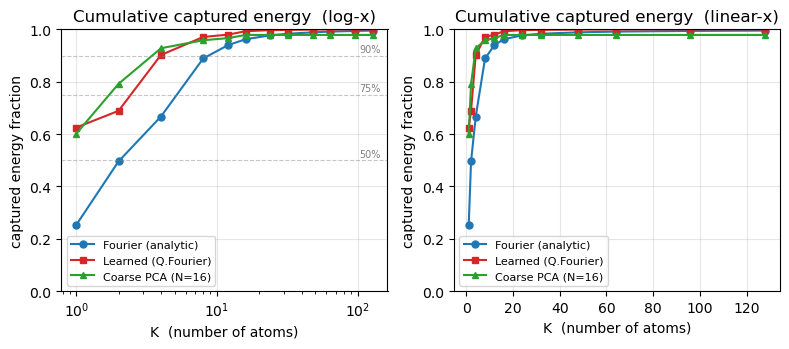

In [9]:
# How many atoms to evaluate.
K_LIST = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64, 96, 128]

# Fine grid + zero log-abs-det for L2 inner products.
coords_proj  = x_fine.to(device)                                # (N_FINE, 1)
lad_proj     = torch.zeros(coords_proj.shape[0], device=device)
N            = coords_proj.shape[0]

# Centre the corpus by the trained mean function.
with torch.no_grad():
    mu_fine = mean_function(coords_proj).cpu()                  # (N_FINE, 1)
corpus_centered = (corpus_fine - mu_fine.unsqueeze(0)).to(device)  # (M, N_FINE, 1)
total_energy = (corpus_centered ** 2).sum(dim=(1, 2)).sum().item() / N
print(f"Total centred L2 energy: {total_energy:.4f}")

# Pre-build a high-truncation atom set so we have >= max(K_LIST) atoms.
K_TRUNC_PROJ = 80                                                # 2.K-1 = 159 atoms
indices_proj = initial_dictionary.get_truncated_indices(K_TRUNC_PROJ).to(device)
nu_proj      = initial_dictionary.get_index_pmfs(indices_proj)
order_proj   = nu_proj.argsort(descending=True)
indices_proj = indices_proj[order_proj]
print(f"Total projection atoms available: {indices_proj.shape[0]}")

def captured_curve(atoms, corpus_centered):
    # atoms: (A, N, 1), corpus_centered: (M, N, 1).
    # Discrete L2 inner product: c[m,a] = (1/N) sum_n atom[a,n] f[m,n]
    A = atoms.shape[0]
    coeffs = torch.einsum("anC,mnC->ma", atoms, corpus_centered) / N    # (M, A)
    energies_per_atom = (coeffs ** 2).sum(dim=0)                       # (A,)
    cum = torch.cumsum(energies_per_atom, dim=0)
    return cum.cpu().numpy()

# Fourier captured curve.
neural_isometry.shuffle_model_state(**model_state_kwargs)
with torch.no_grad():
    atoms_F = initial_dictionary.get_atoms(coords_proj, indices_proj)  # (A, N, 1)
    cum_F   = captured_curve(atoms_F, corpus_centered)

    # Learned: push each Fourier atom forward.
    _, _, atoms_L = neural_isometry.pushforward(
        coords_proj, lad_proj, atoms_F, **pullback_kwargs,
    )
    cum_L = captured_curve(atoms_L, corpus_centered)

# Coarse PCA: interpolate each PC vector to the fine grid (linear interp).
xc_np   = x_coarse.squeeze(-1).numpy()
xf_np   = x_fine.squeeze(-1).numpy()
n_pcs   = Vh.shape[0]
pcs_fine = np.stack(
    [np.interp(xf_np, xc_np, Vh[k].cpu().numpy()) for k in range(n_pcs)], axis=0,
)  # (n_pcs, N_FINE)
# Re-normalize each interpolated PC to unit L2 norm on the fine grid.
pcs_fine_t = torch.from_numpy(pcs_fine).double().to(device)              # (n_pcs, N_FINE)
pcs_norm_l2 = ((pcs_fine_t ** 2).sum(dim=1) / N).sqrt().clamp(min=1e-12)
pcs_fine_t = pcs_fine_t / pcs_norm_l2.unsqueeze(-1)
atoms_PCA = pcs_fine_t.unsqueeze(-1)                                    # (n_pcs, N_FINE, 1)
# Use the coarse mean (also linear-interpolated) for centering - captures the
# real discretization gap (training corpus has the wrong mean too).
mu_coarse_fine = torch.from_numpy(np.interp(xf_np, xc_np, mean_coarse.numpy())).double()
corpus_for_pca = (corpus_fine.squeeze(-1) - mu_coarse_fine.unsqueeze(0))
corpus_for_pca = corpus_for_pca.unsqueeze(-1).to(device)                # (M, N_FINE, 1)
cum_PCA_unc    = captured_curve(atoms_PCA, corpus_for_pca)

# Captured fraction relative to total centred energy.
ks_avail = list(range(1, indices_proj.shape[0] + 1))
ks_pcs   = list(range(1, n_pcs + 1))
def at_k(cum, K, ks):
    K_eff = min(K, ks[-1])
    return cum[K_eff - 1]

frac_F   = [at_k(cum_F,       K, ks_avail) / total_energy for K in K_LIST]
frac_L   = [at_k(cum_L,       K, ks_avail) / total_energy for K in K_LIST]
frac_PCA = [at_k(cum_PCA_unc, K, ks_pcs)   / total_energy for K in K_LIST]

fig, _ = plot_spectral_compactness(
    [
        dict(label="Fourier (analytic)",         xs=K_LIST, mean=frac_F,   color="C0", marker='o'),
        dict(label="Learned (Q.Fourier)",        xs=K_LIST, mean=frac_L,   color="C3", marker='s'),
        dict(label=f"Coarse PCA (N={N_COARSE})", xs=K_LIST, mean=frac_PCA, color="C2", marker='^'),
    ],
    figsize=(8, 3.6),
    xlabel="K  (number of atoms)",
)
plt.tight_layout(); plt.show()

### Discussion

* **Fourier** is suboptimal because the dataset has a **jump discontinuity** at
  $x=0.5$ — Fourier coefficients of a function with a step decay only like
  $1/k$, so capturing the corpus to high accuracy needs many atoms.
* **Learned** rotates the Fourier basis to concentrate the energy of this
  specific corpus into a few atoms — the curve should sit above Fourier for
  every $K$ if training has converged.
* **Coarse PCA** loses information at every projection because the principal
  vectors (defined on $N_{\rm coarse}=16$ points) cannot resolve the jump at
  $x=0.5$ once interpolated to the fine grid. The gap between Learned and
  Coarse PCA is exactly the **discretization error** that an "infinite-dim"
  isometry like ours avoids.


## 8. Cayley vs. backward-Euler vs. forward-Euler — energy preservation

Three integrators sharing the **same generator** K:

| method | step | property |
|---|---|---|
| **Cayley** (default) | $f \mapsto (I-\beta K)^{-1}(I+\beta K)\,f$, $\beta = \tfrac{1}{2}\Delta t \cdot a$ | **norm-preserving** (orthogonal) |
| **backward-Euler** (implicit) | $f \mapsto (I - \Delta t \cdot a \cdot K)^{-1}\,f$ | **dissipative**; unconditionally stable |
| **forward-Euler** (explicit) | $f \mapsto f + \Delta t \cdot a \cdot K \, f$ | naive; **blows up** when $\Delta t \cdot \|K\| \gtrsim 1$ |

We push the **first Fourier atom** through the trained isometry under each integrator. **Each snapshot is integrated from-scratch** (`pushforward(0 → t[i])`) with its own `num_steps[i]`, so snapshots are independent — no compounding discretisation across them.

### Knobs to tune

| name | meaning |
|---|---|
| `SNAPSHOT_TIMES` | irregular times at which we snapshot $f$ |
| `NUM_STEPS_PER_SNAPSHOT` | one entry per snapshot — `num_steps` for `pushforward(0 → t[i])` (entry 0 is unused since $t=0$) |
| `ATOM_RANK` | which Fourier atom (0 = highest-PMF / DC; 1 = first oscillatory; …) |

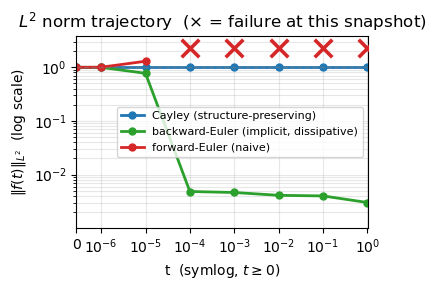

f = Fourier atom rank 0  (DC/constant mode, phi(x)=1)
||f0||_L2 = 1.000000000000
  cayley            ['1.0000e+00', '1.0000e+00', '1.0000e+00', '1.0000e+00', '1.0000e+00', '1.0000e+00', '1.0000e+00', '1.0000e+00']  (failed: [])
  backward-euler    ['1.0000e+00', '9.9741e-01', '7.7205e-01', '4.8536e-03', '4.6529e-03', '4.1202e-03', '4.0162e-03', '3.0277e-03']  (failed: [])
  forward-euler     ['1.0000e+00', '1.0026e+00', '1.2957e+00', '1.0900e+10', '1.0614e+142', 'inf', 'inf', 'nan']  (failed: [0.0001, 0.001, 0.01, 0.1, 1.0])


In [10]:
from infidictionary.utils import norm2

# ─── tunable knobs ──────────────────────────────────────────────────────────
SNAPSHOT_TIMES         = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0] # 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,  1.0]
NUM_STEPS_PER_SNAPSHOT = [2,   100,  100,  100,  100,  100,  100, 100] # 100, 100, 100, 100, 100, 100, 100]
ATOM_RANK              = 0        # 0 = highest-PMF Fourier atom (DC / constant mode in 1-D)
ZOOM_THRESH            = 2.5e-11     # half-width of the zoomed middle zone around norm0
SPLIT_ZONES            = False     # False → single log-scale panel; True → three-zone broken axis
X_SCALE                = 'symlog' # 'symlog' or 'linear'
# ────────────────────────────────────────────────────────────────────────────

assert len(NUM_STEPS_PER_SNAPSHOT) == len(SNAPSHOT_TIMES), (
    f'NUM_STEPS_PER_SNAPSHOT must have length {len(SNAPSHOT_TIMES)} '
    f'(one per snapshot, entry 0 unused); got {len(NUM_STEPS_PER_SNAPSHOT)}.'
)

N_TEST   = 1024
x_test   = LineSegmentSampler(stratified=True, add_noise=False).sample(N_TEST).to(device)
lad_test = torch.zeros(N_TEST, device=device)

# f0 = ATOM_RANK-th Fourier atom sorted by PMF descending.
# Rank 0 is the DC atom: phi(x)=1 everywhere, L2-normalized so ||f0||=1.
with torch.no_grad():
    _idx_all = initial_dictionary.get_truncated_indices(2).to(device)
    _nu_all  = initial_dictionary.get_index_pmfs(_idx_all)
    _order   = _nu_all.argsort(descending=True)
    _chosen  = _idx_all[_order][ATOM_RANK:ATOM_RANK + 1]
    f0       = initial_dictionary.get_atoms(x_test, _chosen)               # (1, N, 1)

ts      = np.asarray(SNAPSHOT_TIMES, dtype=float)
methods = ['cayley', 'backward-euler', 'forward-euler']

with torch.no_grad():
    norm0  = norm2(f0, lad_test).item()
    norms  = {m: [norm0] for m in methods}
    frames = {m: [f0[0].clone()] for m in methods}

    # Each snapshot integrated from-scratch (0 -> t[i]) with its own num_steps[i].
    for m in methods:
        for i in range(1, len(SNAPSHOT_TIMES)):
            t_target = SNAPSHOT_TIMES[i]
            neural_isometry.shuffle_model_state(num_steps=NUM_STEPS_PER_SNAPSHOT[i])
            _, _, f_i = neural_isometry.pushforward(
                x_test, lad_test, f0, 0.0, t_target, method=m,
            )
            norms[m].append(norm2(f_i, lad_test).item())
            frames[m].append(f_i[0].clone())

STYLES = {
    'cayley':         dict(color='C0', label='Cayley (structure-preserving)'),
    'backward-euler': dict(color='C2', label='backward-Euler (implicit, dissipative)'),
    'forward-euler':  dict(color='C3', label='forward-Euler (naive)'),
}

explosion_threshold = 1e3 * norm0

def _failure_mask(arr):
    a = np.asarray(arr, dtype=float)
    return (~np.isfinite(a)) | (a > explosion_threshold)

def _set_time_axis(ax):
    if X_SCALE == 'symlog':
        ax.set_xscale('symlog', linthresh=max(min(ts[ts > 0]) / 2, 1e-6), linscale=0.5)
        ax.set_xlabel(r't  (symlog, $t \geq 0$)')
    else:
        ax.set_xscale('linear')
        ax.set_xlabel('t')
    ax.set_xlim(0, max(ts) * 1.05)

# ── Gather finite values for dynamic y-bounds ────────────────────────────────
all_finite = np.concatenate([
    np.asarray(norms[m])[
        np.isfinite(np.asarray(norms[m])) & (np.asarray(norms[m]) < explosion_threshold)
    ]
    for m in methods
])

# ═══════════════════════════════════════════════════════════════════════════════
if not SPLIT_ZONES:
    # ── Single log-scale panel ────────────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))

    for m in methods:
        arr   = np.asarray(norms[m], dtype=float)
        valid = ~_failure_mask(arr)
        if valid.any():
            ax.semilogy(ts[valid], arr[valid], lw=2, marker='o', markersize=5, **STYLES[m])

    pos_vals = all_finite[all_finite > 0]
    y_top = pos_vals.max() * 3     if pos_vals.size else explosion_threshold
    y_bot = pos_vals.min() / 3     if pos_vals.size else norm0 * 1e-4

    for m in methods:
        arr  = np.asarray(norms[m], dtype=float)
        fail = _failure_mask(arr)
        if fail.any():
            ax.scatter(ts[fail], np.full(fail.sum(), y_top * 0.6),
                       marker='x', s=160, linewidths=2.6, zorder=10,
                       color=STYLES[m]['color'])

    ax.axhline(norm0, color='gray', ls='--', alpha=0.5, lw=1.0)
    ax.set_ylim(y_bot, y_top)
    _set_time_axis(ax)
    ax.set_ylabel(r'$\|f(t)\|_{L^2}$  (log scale)')
    ax.set_title(r'$L^2$ norm trajectory  ($\times$ = failure at this snapshot)')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3, which='both')
    plt.tight_layout()

# ═══════════════════════════════════════════════════════════════════════════════
else:
    # ── Three-zone broken-axis figure ─────────────────────────────────────────
    y_mid_lo = norm0 - ZOOM_THRESH
    y_mid_hi = norm0 + ZOOM_THRESH

    above = all_finite[all_finite > y_mid_hi]
    below = all_finite[(all_finite < y_mid_lo) & (all_finite > 0)]

    y_top_lo = y_mid_hi
    y_top_hi = float(above.max()) * 5 if above.size else y_mid_hi * 10
    y_bot_lo = float(below.min()) / 3 if below.size else y_mid_lo * 1e-3
    y_bot_hi = y_mid_lo

    fig = plt.figure(figsize=(4, 3))
    gs  = fig.add_gridspec(3, 1, hspace=0, height_ratios=[3, 1, 3])
    ax_top = fig.add_subplot(gs[0])
    ax_mid = fig.add_subplot(gs[1], sharex=ax_top)
    ax_bot = fig.add_subplot(gs[2], sharex=ax_top)

    ax_top.set_ylim(y_top_lo, y_top_hi)
    ax_mid.set_ylim(y_mid_lo, y_mid_hi)
    ax_bot.set_ylim(y_bot_lo, y_bot_hi)
    ax_top.set_yscale('log')
    ax_bot.set_yscale('log')
    # ax_mid stays linear (tiny +/-ZOOM_THRESH band around norm0)

    # Light blue tint on the zoomed middle zone
    ax_mid.set_facecolor('#ddeeff')

    # Plot in each zone using nan-masking to avoid the repeated-chart artifact.
    zones = [(ax_top, y_top_lo, y_top_hi),
             (ax_mid, y_mid_lo, y_mid_hi),
             (ax_bot, y_bot_lo, y_bot_hi)]

    for m in methods:
        arr = np.asarray(norms[m], dtype=float)
        for ax, y_lo, y_hi in zones:
            in_zone = np.isfinite(arr) & (arr >= y_lo) & (arr <= y_hi)
            masked  = np.where(in_zone, arr, np.nan)
            ax.plot(ts, masked, lw=2, marker='o', markersize=5, **STYLES[m])

    # Reference dashed line at norm0 inside the middle zone
    ax_mid.axhline(norm0, color='gray', ls='--', alpha=0.6, lw=1.0)
    ax_mid.set_yticks([y_mid_lo, norm0, y_mid_hi])
    ax_mid.set_yticklabels(
        [f'1$-${ZOOM_THRESH:.0e}', '1', f'1$+${ZOOM_THRESH:.0e}'], fontsize=8
    )

    # Failure x markers near the top of the top zone
    for m in methods:
        arr  = np.asarray(norms[m], dtype=float)
        fail = _failure_mask(arr)
        if fail.any():
            ax_top.scatter(ts[fail], np.full(fail.sum(), y_top_hi * 0.55),
                           marker='x', s=160, linewidths=2.6, zorder=10,
                           color=STYLES[m]['color'])

    # Hide spines at zone breaks and add diagonal break marks
    ax_top.spines['bottom'].set_visible(False)
    ax_mid.spines['top'].set_visible(False)
    ax_mid.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax_top.tick_params(bottom=False)
    ax_mid.tick_params(bottom=False, top=False)
    ax_bot.tick_params(top=False)

    d = 0.012
    for ax, draw_bot, draw_top in [
        (ax_top, True,  False),
        (ax_mid, True,  True),
        (ax_bot, False, True),
    ]:
        kw = dict(color='k', clip_on=False, lw=1.2, transform=ax.transAxes)
        if draw_bot:
            ax.plot((-d, +d), (-d, +d), **kw)
            ax.plot((1 - d, 1 + d), (-d, +d), **kw)
        if draw_top:
            ax.plot((-d, +d), (1 - d, 1 + d), **kw)
            ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kw)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_mid.get_xticklabels(), visible=False)
    _set_time_axis(ax_bot)

    fig.text(0.04, 0.5, r'$\|f(t)\|_{L^2}$', va='center', rotation='vertical', fontsize=12)
    ax_top.set_title(
        r'$L^2$ norm trajectory — broken y-axis'
        f'  (middle band: $\\|f_0\\| \\pm {ZOOM_THRESH:.0e}$,  $\\times$ = failure)'
    )
    ax_top.legend(loc='upper right', fontsize=8)

    for ax in (ax_top, ax_mid, ax_bot):
        ax.grid(alpha=0.3, which='both')

    plt.tight_layout(rect=[0.06, 0, 1, 1])

plt.show()

print(f'f = Fourier atom rank {ATOM_RANK}  (DC/constant mode, phi(x)=1)')
print(f'||f0||_L2 = {norm0:.12f}')
for m in methods:
    arr  = np.asarray(norms[m], dtype=float)
    fail = _failure_mask(arr)
    print(f'  {m:16s}  {[f"{v:.4e}" for v in arr]}  (failed: {ts[fail].tolist()})')


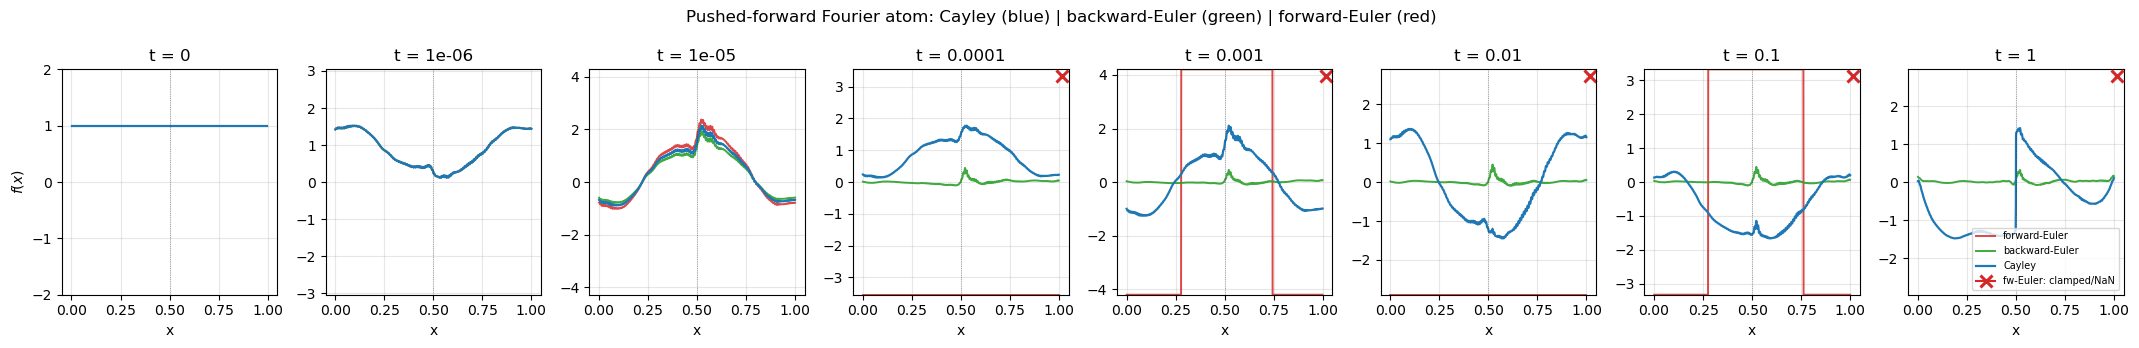

In [11]:
# One panel per SNAPSHOT_TIMES entry. Per-panel y-range anchored on Cayley.
# Failure/clamp state shown as a × in the top-right corner instead of text boxes.

# ─── visualisation knobs ────────────────────────────────────────────────────
PANEL_YMAX_FACTOR = 2.0   # per-panel y-range = ±factor × Cayley's peak in that panel
# ────────────────────────────────────────────────────────────────────────────

snap_idxs = list(range(len(SNAPSHOT_TIMES)))

x_np     = x_test.squeeze(-1).cpu().numpy()
order_x  = np.argsort(x_np)
x_sorted = x_np[order_x]

# Collect which panels have each failure mode so we can build a clean legend once.
_clamped_panels = []
_nan_panels     = []

fig, axes = plt.subplots(1, len(snap_idxs), figsize=(2.7 * len(snap_idxs), 3.5),
                         sharey=False)

for col, k in enumerate(snap_idxs):
    ax = axes[col]
    fc_v = frames['cayley'][k].squeeze(-1).cpu().numpy()[order_x]
    fb_v = frames['backward-euler'][k].squeeze(-1).cpu().numpy()[order_x]
    fn_v = frames['forward-euler'][k].squeeze(-1).cpu().numpy()[order_x]

    cayley_peak = float(np.abs(fc_v).max()) + 1e-12
    ymax_panel  = PANEL_YMAX_FACTOR * cayley_peak

    # forward-Euler: plot if finite (clamped to panel range), skip if NaN
    if np.isfinite(fn_v).all():
        fn_clamped = np.clip(fn_v, -ymax_panel, ymax_panel)
        ax.plot(x_sorted, fn_clamped, color='C3', lw=1.4, alpha=0.85,
                label='forward-Euler')
        if np.abs(fn_v).max() > ymax_panel:
            # × in top-right corner to signal clamping
            ax.plot(0.97, 0.97, marker='x', ms=9, mew=2.2, color='C3',
                    transform=ax.transAxes, clip_on=False, zorder=2,
                    label='fw-Euler: clamped')
            _clamped_panels.append(col)
    else:
        # NaN — nothing to plot; × in top-right corner
        ax.plot(0.97, 0.97, marker='x', ms=9, mew=2.2, color='C3',
                transform=ax.transAxes, clip_on=False, zorder=10,
                label='fw-Euler: NaN')
        _nan_panels.append(col)

    ax.plot(x_sorted, fb_v, color='C2', lw=1.4, alpha=0.9, label='backward-Euler')
    ax.plot(x_sorted, fc_v, color='C0', lw=1.6, label='Cayley')

    ax.axvline(0.5, color='k', ls=':', lw=0.6, alpha=0.4)
    ax.set_title(f't = {SNAPSHOT_TIMES[k]:g}')
    ax.set_xlabel('x')
    ax.grid(alpha=0.3)
    ax.set_ylim(-ymax_panel, ymax_panel)
    if col == 0:
        ax.set_ylabel(r'$f(x)$')

# Build a single shared legend in the last panel, deduplicating labels.
ax_last = axes[-1]
handles, labels = [], []
seen = set()
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        # Collapse clamped / NaN variants into one entry per state
        key = l if l not in ('fw-Euler: clamped', 'fw-Euler: NaN') else 'fw-Euler: clamped/NaN'
        if key not in seen:
            seen.add(key)
            handles.append(h)
            labels.append(key)
ax_last.legend(handles, labels, fontsize=7, loc='lower right')

fig.suptitle('Pushed-forward Fourier atom: Cayley (blue) | backward-Euler (green) | forward-Euler (red)')
plt.tight_layout()
plt.show()


## 9. Gram matrix evolution (Cayley)

Push the first $N$ Fourier atoms through the Cayley integrator at each snapshot time and compute
the discrete $L^2$ Gram matrix

$$G_{ij}(t) = \langle Q(t)\phi_i,\, Q(t)\phi_j \rangle = \frac{1}{N}\sum_n [Q(t)\phi_i](x_n)\,[Q(t)\phi_j](x_n).$$

Because Cayley is an exact unitary map, $G(t)$ must equal the identity for **all** $t$ — the
diagonal stays 1 and every off-diagonal stays 0 regardless of how large $t$ is.
Each panel shows one snapshot from §8; the Frobenius error $\|G(t)-I\|_F$ is printed below.

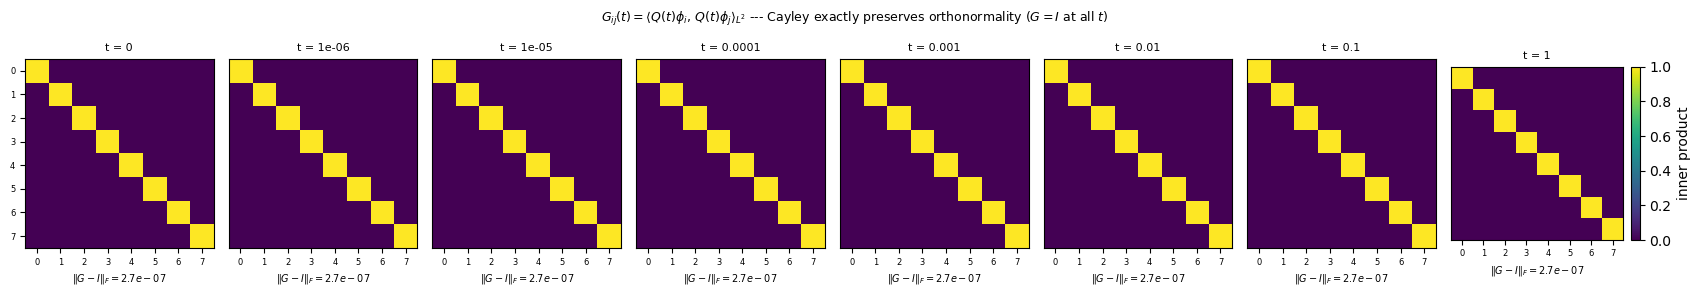

In [12]:
# ─── knobs ──────────────────────────────────────────────────────────────────
N_ATOMS_GRAM = 8    # first N atoms by PMF — Cayley must keep G = I at all t
# Reads SNAPSHOT_TIMES and NUM_STEPS_PER_SNAPSHOT from §8.
# ────────────────────────────────────────────────────────────────────────────

# First N_ATOMS_GRAM Fourier atoms by PMF descending.
_idx_g = initial_dictionary.get_truncated_indices(N_ATOMS_GRAM + 2).to(device)
_nu_g  = initial_dictionary.get_index_pmfs(_idx_g)
_idx_g = _idx_g[_nu_g.argsort(descending=True)][:N_ATOMS_GRAM]

x_gram   = LineSegmentSampler(stratified=True, add_noise=False).sample(1024).to(device)
lad_gram = torch.zeros(x_gram.shape[0], device=device)
N_GRAM   = x_gram.shape[0]

with torch.no_grad():
    atoms_src = initial_dictionary.get_atoms(x_gram, _idx_g)   # (N_ATOMS_GRAM, N, 1)

# Gram matrix at each snapshot via Cayley (independent pushforward per snapshot).
gram_mats = []
for i, t_target in enumerate(SNAPSHOT_TIMES):
    if t_target == 0.0:
        a = atoms_src.squeeze(-1)
    else:
        neural_isometry.shuffle_model_state(num_steps=NUM_STEPS_PER_SNAPSHOT[i])
        with torch.no_grad():
            _, _, pushed = neural_isometry.pushforward(
                x_gram, lad_gram, atoms_src, 0.0, t_target, method='cayley',
            )
        a = pushed.squeeze(-1)
    G = (a @ a.T / N_GRAM).cpu().numpy()
    gram_mats.append(G)

# ── Plot ─────────────────────────────────────────────────────────────────────
n_snaps = len(SNAPSHOT_TIMES)
fig, axes = plt.subplots(1, n_snaps,
                         figsize=(2.15 * n_snaps, 2.7),
                         squeeze=False)
I_ref = np.eye(N_ATOMS_GRAM)

for j, (G, t) in enumerate(zip(gram_mats, SNAPSHOT_TIMES)):
    ax = axes[0, j]
    im = ax.imshow(G, vmin=0.0, vmax=1.0, cmap='viridis',
                   aspect='equal', interpolation='nearest')
    frob = np.sqrt(np.sum((G - I_ref) ** 2))
    ax.set_title(f't = {t:g}', fontsize=8)
    ax.set_xlabel(rf'$\|G-I\|_F={frob:.1e}$', fontsize=7)
    ax.set_xticks(range(N_ATOMS_GRAM))
    ax.set_yticks(range(N_ATOMS_GRAM) if j == 0 else [])
    ax.tick_params(labelsize=6)

plt.colorbar(im, ax=axes[0, -1], fraction=0.046, pad=0.04, label='inner product')
fig.suptitle(
    r'$G_{ij}(t) = \langle Q(t)\phi_i,\, Q(t)\phi_j\rangle_{L^2}$'
    ' --- Cayley exactly preserves orthonormality ($G = I$ at all $t$)',
    fontsize=9,
)
plt.tight_layout(); plt.show()